<ipython-input-1-edca4bcf0f6e>:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

dataset_size:
train_dataset: 20000
valid_dataset: 5000
test_dataset: 25000
smaple:
text: Not wishing to give *anything* away here, I would just say this technically excellent, flawlessly ac...
label: positive
label distrubitions:
train_dataset - positive(1): 10009
train_dataset - negative(0): 9991
valid_dataset - positive(1): 2491
valid_dataset - negative(0): 2509
test_dataset - positive(1): 12500
test_dataset - negative(0): 12500

TRAIN文本长度统计:
样本数量: 20000
最小长度: 10
最大长度: 1839
平均长度: 233.1
中位数: 174.0
标准差: 172.9
75%分位数: 283.0
95%分位数: 599.0
超过BERT最大长度的比例: 73.66%

VALID文本长度统计:
样本数量: 5000
最小长度: 10
最大长度: 2470
平均长度: 236.4
中位数: 174.0
标准差: 177.1
75%分位数: 289.0
95%分位数: 598.0
超过BERT最大长度的比例: 74.60%

TEST文本长度统计:
样本数量: 25000
最小长度: 4
最大长度: 2278
平均长度: 228.5
中位数: 172.0
标准差: 168.9
75%分位数: 277.0
95%分位数: 582.0499999999993
超过BERT最大长度的比例: 73.06%

ALL文本长度统计:
样本数量: 50000
最小长度: 4
最大长度: 2470
平均长度: 231.2
中位数: 173.0
标准差: 171.3
75%分位数: 280.0
95%分位数: 590.0
超过BERT最大长度的比例: 73.45%


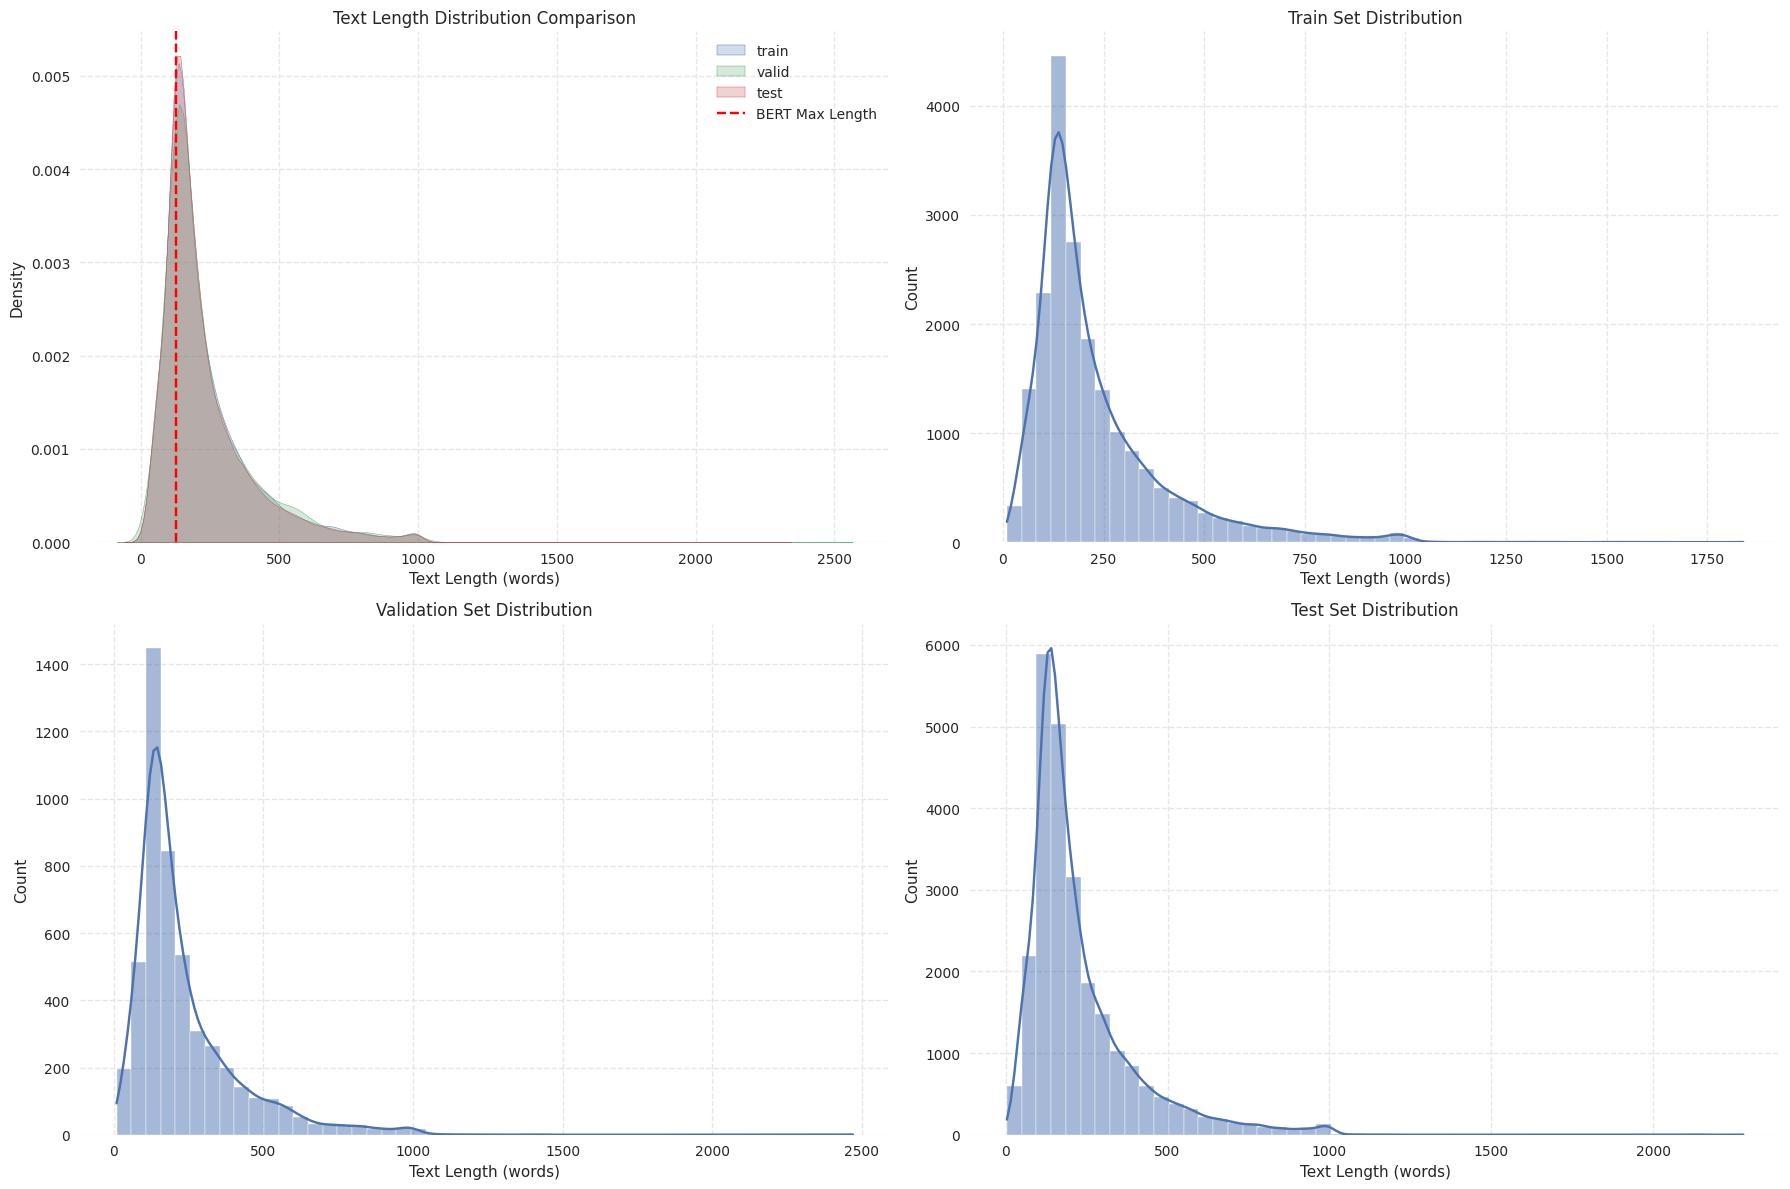

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from datasets import load_dataset, DatasetDict
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) 
import seaborn as sns
from torch import nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import time
plt.style.use('seaborn')
from tqdm import tqdm

class IMDBDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        text = self.dataset[idx]['text']
        label = self.dataset[idx]['label']
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()
        label = torch.tensor(label, dtype=torch.long)
        return input_ids, attention_mask, label

def plot_all_distributions(datasets):
    sns.set_style("white")
    plt.figure(figsize=(18, 12), facecolor='white')
    sns.set_style("whitegrid", {
    'axes.facecolor': 'white',
    'grid.color': '.9',
    'grid.linestyle': '--',
    'axes.edgecolor': '.9' 
    })
    plt.subplot(2, 2, 1)
    for name, data in datasets.items():
        sns.kdeplot(data['lengths'], label=name, fill=True)
    plt.title('Text Length Distribution Comparison')
    plt.xlabel('Text Length (words)')
    plt.ylabel('Density')
    plt.legend()
    plt.axvline(x=128, color='red', linestyle='--', label='BERT Max Length')
    plt.legend()
    plt.subplot(2, 2, 2)
    sns.histplot(datasets['train']['lengths'], bins=50, kde=True)
    plt.title('Train Set Distribution')
    plt.xlabel('Text Length (words)')
    plt.subplot(2, 2, 3)
    sns.histplot(datasets['valid']['lengths'], bins=50, kde=True)
    plt.title('Validation Set Distribution')
    plt.xlabel('Text Length (words)')
    plt.subplot(2, 2, 4)
    sns.histplot(datasets['test']['lengths'], bins=50, kde=True)
    plt.title('Test Set Distribution')
    plt.xlabel('Text Length (words)')
    
    plt.tight_layout()
    plt.show()

def print_statistics(name, lengths):
    print(f"\n{name}文本长度统计:")
    print(f"样本数量: {len(lengths)}")
    print(f"最小长度: {min(lengths)}")
    print(f"最大长度: {max(lengths)}")
    print(f"平均长度: {np.mean(lengths):.1f}")
    print(f"中位数: {np.median(lengths)}")
    print(f"标准差: {np.std(lengths):.1f}")
    print(f"75%分位数: {np.percentile(lengths, 75)}")
    print(f"95%分位数: {np.percentile(lengths, 95)}")
    truncated = sum(1 for l in lengths if l > 128)
    print(f"超过BERT最大长度的比例: {truncated/len(lengths):.2%}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = load_dataset('imdb')
train_testvalid = dataset['train'].train_test_split(test_size=0.2)
dataset_dict = DatasetDict({
    'train': train_testvalid['train'],
    'valid': train_testvalid['test'],
    'test': dataset['test']
})
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
max_length = 128

# 创建数据集并收集长度信息
datasets = {
    'train': {'dataset': IMDBDataset(dataset_dict['train'], tokenizer, max_length)},
    'valid': {'dataset': IMDBDataset(dataset_dict['valid'], tokenizer, max_length)},
    'test': {'dataset': IMDBDataset(dataset_dict['test'], tokenizer, max_length)}
}

print("dataset_size:")
train_dataset = IMDBDataset(dataset_dict['train'], tokenizer, max_length)
valid_dataset = IMDBDataset(dataset_dict['valid'], tokenizer, max_length)
test_dataset = IMDBDataset(dataset_dict['test'], tokenizer, max_length)
print(f"train_dataset: {len(train_dataset)}")
print(f"valid_dataset: {len(valid_dataset)}")
print(f"test_dataset: {len(test_dataset)}")
print("smaple:")
print("text:", train_dataset.dataset[0]['text'][:100] + "...")
print("label:", "positive" if train_dataset.dataset[0]['label'] == 1 else "negative")
train_labels = [sample['label'] for sample in train_dataset.dataset]
valid_labels = [sample['label'] for sample in valid_dataset.dataset]
test_labels = [sample['label'] for sample in test_dataset.dataset]
print("label distrubitions:")
print("train_dataset - positive(1):", np.sum(train_labels))
print("train_dataset - negative(0):", len(train_labels) - np.sum(train_labels))
print("valid_dataset - positive(1):", np.sum(valid_labels))
print("valid_dataset - negative(0):", len(valid_labels) - np.sum(valid_labels))
print("test_dataset - positive(1):", np.sum(test_labels))
print("test_dataset - negative(0):", len(test_labels) - np.sum(test_labels))

for name in datasets:
    datasets[name]['lengths'] = [
        len(sample['text'].split()) 
        for sample in datasets[name]['dataset'].dataset
    ]
    print_statistics(name.upper(), datasets[name]['lengths'])
all_lengths = []
for name in datasets:
    all_lengths.extend(datasets[name]['lengths'])

print_statistics("ALL", all_lengths)
plot_all_distributions(datasets)

batch_size = 32
train_loader = DataLoader(datasets['train']['dataset'], batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(datasets['valid']['dataset'], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(datasets['test']['dataset'], batch_size=batch_size, shuffle=False)

In [2]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [3]:
class TransformerModel(nn.Module):
    def __init__(self, num_heads, d_model, num_classes):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Embedding(30522, d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)
        attn_output, _ = self.attn(x, x, x)
        attn_output = attn_output.permute(1, 0, 2)
        out = attn_output.mean(dim=1)
        out = self.fc(out)
        return out

In [4]:
def train_model_with_test_accuracy(model, train_loader, val_loader, test_loader, criterion, optimizer, device, epochs, model_name):
    model.train()
    best_val_accuracy = 0
    val_accuracies = []
    train_accuracies = []
    train_losses = []
    best_epoch = 0
    st_time = time.time()
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        running_loss = 0
        start_time = time.time()
        model.train()
        for batch_input_ids, batch_attention_mask, batch_labels in tqdm(train_loader, desc="Training"):
            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()
            if isinstance(model, AutoModelForSequenceClassification):
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask, labels=batch_labels)
                loss = outputs.loss
            else:
                outputs = model(batch_input_ids)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        model.eval()
        train_accuracy = evaluate_model(model, train_loader, device)
        val_accuracy = evaluate_model(model, val_loader, device)
        #test_accuracy = evaluate_model(model, test_loader, device)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print(f"训练损失: {epoch_loss}, 训练准确率: {train_accuracy}, 验证准确率: {val_accuracy}")
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'best_{model_name}_model.pth')
        print(f"Epoch {epoch + 1} 完成, 耗时: {time.time() - start_time:.2f}s")
    print(f"best_epoch: {best_epoch}")
    ed_time = time.time()
    print(f"all_time: {ed_time-st_time}")
    return {
        'val_accuracies': val_accuracies,
        'train_accuracies': train_accuracies,
        'train_losses': train_losses,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_accuracy
    }
    
def evaluate_model(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_input_ids, batch_attention_mask, batch_labels in tqdm(val_loader, desc="Evaluating"):
            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_labels = batch_labels.to(device)
            if isinstance(model, AutoModelForSequenceClassification):
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
                _, predicted = torch.max(outputs.logits, 1)
            else:
                outputs = model(batch_input_ids)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    accuracy = correct / total
    return accuracy

In [5]:
def evaluate_model_final(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0
    positive_correct = 0
    positive_total = 0
    negative_correct = 0
    negative_total = 0
    
    with torch.no_grad():
        for batch_input_ids, batch_attention_mask, batch_labels in tqdm(val_loader, desc="Evaluating"):
            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_labels = batch_labels.to(device)
            
            if isinstance(model, AutoModelForSequenceClassification):
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
                _, predicted = torch.max(outputs.logits, 1)
            else:
                outputs = model(batch_input_ids)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                _, predicted = torch.max(outputs, 1)
            
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
            positive_mask = (batch_labels == 1)
            positive_total += positive_mask.sum().item()
            positive_correct += ((predicted == batch_labels) & positive_mask).sum().item()
            negative_mask = (batch_labels == 0)
            negative_total += negative_mask.sum().item()
            negative_correct += ((predicted == batch_labels) & negative_mask).sum().item()
    
    accuracy = correct / total
    positive_accuracy = positive_correct / positive_total if positive_total > 0 else 0
    negative_accuracy = negative_correct / negative_total if negative_total > 0 else 0
    
    return {
        'overall_accuracy': accuracy,
        'positive_accuracy': positive_accuracy,
        'negative_accuracy': negative_accuracy
    }

In [6]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
max_name_len = max(len(name) for name, _ in model.named_parameters())
max_shape_len = max(len(str(param.shape)) for _, param in model.named_parameters())
print(f"{'Parameter Name'.ljust(max_name_len)} | {'Shape'.ljust(max_shape_len)} | Requires Grad")
print("-" * (max_name_len + max_shape_len + 20))
for name, param in model.named_parameters():
    print(
        f"{name.ljust(max_name_len)} | "
        f"{str(param.shape).ljust(max_shape_len)} | "
        f"{param.requires_grad}"
    )

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameter Name                                          | Shape                    | Requires Grad
---------------------------------------------------------------------------------------------------
bert.embeddings.word_embeddings.weight                  | torch.Size([30522, 768]) | True
bert.embeddings.position_embeddings.weight              | torch.Size([512, 768])   | True
bert.embeddings.token_type_embeddings.weight            | torch.Size([2, 768])     | True
bert.embeddings.LayerNorm.weight                        | torch.Size([768])        | True
bert.embeddings.LayerNorm.bias                          | torch.Size([768])        | True
bert.encoder.layer.0.attention.self.query.weight        | torch.Size([768, 768])   | True
bert.encoder.layer.0.attention.self.query.bias          | torch.Size([768])        | True
bert.encoder.layer.0.attention.self.key.weight          | torch.Size([768, 768])   | True
bert.encoder.layer.0.attention.self.key.bias            | torch.Size([768])      

In [7]:
vocab_size = len(tokenizer.vocab)
model = LSTMModel(vocab_size, embedding_dim=128, hidden_dim=256, num_classes=2)
max_name_len = max(len(name) for name, _ in model.named_parameters())
max_shape_len = max(len(str(param.shape)) for _, param in model.named_parameters())
print(f"{'Parameter Name'.ljust(max_name_len)} | {'Shape'.ljust(max_shape_len)} | Requires Grad")
print("-" * (max_name_len + max_shape_len + 20))
for name, param in model.named_parameters():
    print(
        f"{name.ljust(max_name_len)} | "
        f"{str(param.shape).ljust(max_shape_len)} | "
        f"{param.requires_grad}"
    )

Parameter Name    | Shape                    | Requires Grad
-------------------------------------------------------------
embedding.weight  | torch.Size([30522, 128]) | True
lstm.weight_ih_l0 | torch.Size([1024, 128])  | True
lstm.weight_hh_l0 | torch.Size([1024, 256])  | True
lstm.bias_ih_l0   | torch.Size([1024])       | True
lstm.bias_hh_l0   | torch.Size([1024])       | True
fc.weight         | torch.Size([2, 256])     | True
fc.bias           | torch.Size([2])          | True


In [8]:
model = TransformerModel(num_heads=8, d_model=256, num_classes=2)
max_name_len = max(len(name) for name, _ in model.named_parameters())
max_shape_len = max(len(str(param.shape)) for _, param in model.named_parameters())
print(f"{'Parameter Name'.ljust(max_name_len)} | {'Shape'.ljust(max_shape_len)} | Requires Grad")
print("-" * (max_name_len + max_shape_len + 20))
for name, param in model.named_parameters():
    print(
        f"{name.ljust(max_name_len)} | "
        f"{str(param.shape).ljust(max_shape_len)} | "
        f"{param.requires_grad}"
    )

Parameter Name       | Shape                    | Requires Grad
----------------------------------------------------------------
embedding.weight     | torch.Size([30522, 256]) | True
attn.in_proj_weight  | torch.Size([768, 256])   | True
attn.in_proj_bias    | torch.Size([768])        | True
attn.out_proj.weight | torch.Size([256, 256])   | True
attn.out_proj.bias   | torch.Size([256])        | True
fc.weight            | torch.Size([2, 256])     | True
fc.bias              | torch.Size([2])          | True


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20


Evaluating: 100%|██████████| 157/157 [00:41<00:00,  3.80it/s]


训练损失: 0.3686293711781502, 训练准确率: 0.91085, 验证准确率: 0.8742
Epoch 1 完成, 耗时: 679.78s
Epoch 2/20


Evaluating: 100%|██████████| 157/157 [00:41<00:00,  3.79it/s]


...

Evaluating: 100%|██████████| 157/157 [00:41<00:00,  3.79it/s]


训练损失: 0.009345678627293092, 训练准确率: 0.9994, 验证准确率: 0.8832
Epoch 20 完成, 耗时: 689.46s
best_epoch: 17
all_time: 13782.79771065712


Evaluating: 100%|██████████| 782/782 [03:25<00:00,  3.81it/s]


测试集准确率: 0.8832
积极情感准确率: 0.8893
消极情感准确率: 0.8770


Evaluating: 100%|██████████| 782/782 [03:25<00:00,  3.81it/s]


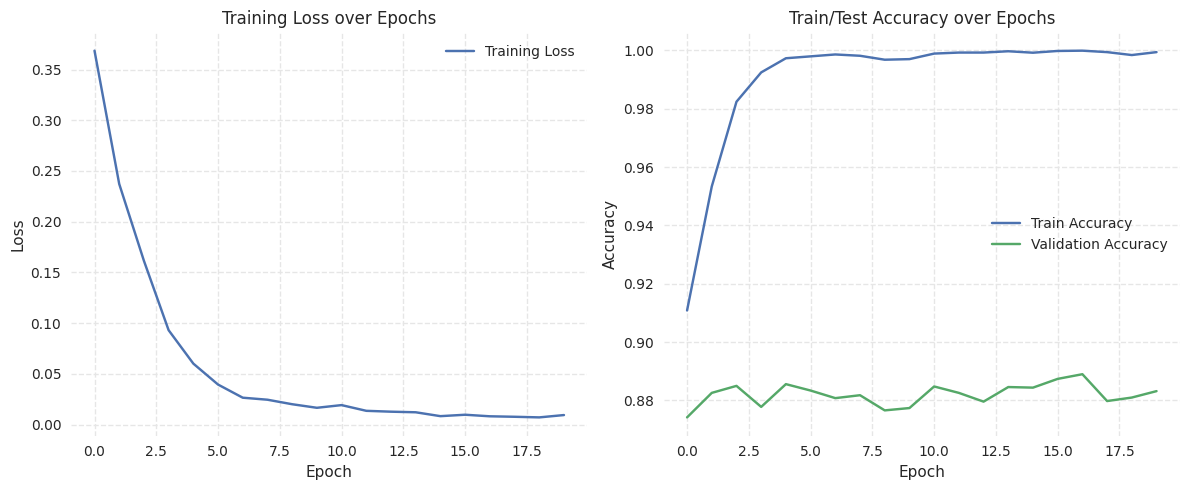

In [9]:
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)
bert_criterion = nn.CrossEntropyLoss()
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=1e-5)

training_metrics = train_model_with_test_accuracy(
    bert_model, train_loader, valid_loader, test_loader, 
    bert_criterion, bert_optimizer, device, epochs=20, model_name="bert"
)

state_dict = torch.load('/kaggle/working/best_bert_model.pth', weights_only=True)
bert_model.load_state_dict(state_dict)
test_results = evaluate_model_final(bert_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

test_results = evaluate_model_final(bert_model, test_loader, device)
bert_loss = training_metrics['train_losses']
bert_train_accuracies = training_metrics['train_accuracies']
bert_val_accuracies = training_metrics['val_accuracies']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(training_metrics['train_losses'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_metrics['train_accuracies'], label='Train Accuracy')
plt.plot(training_metrics['val_accuracies'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/Test Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/20


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 19.97it/s]


训练损失: 0.6927311808586121, 训练准确率: 0.5376, 验证准确率: 0.5266
Epoch 1 完成, 耗时: 76.89s
Epoch 2/20


Evaluating: 100%|██████████| 157/157 [00:08<00:00, 19.35it/s]


训练损失: 0.6761507576942444, 训练准确率: 0.6289, 验证准确率: 0.6202
Epoch 2 完成, 耗时: 77.13s
Epoch 3/20


...

训练损失: 0.3711685013651848, 训练准确率: 0.86615, 验证准确率: 0.7764
Epoch 19 完成, 耗时: 77.04s
Epoch 20/20


Evaluating: 100%|██████████| 157/157 [00:08<00:00, 19.56it/s]


训练损失: 0.3311031010746956, 训练准确率: 0.8839, 验证准确率: 0.7882
Epoch 20 完成, 耗时: 77.35s
best_epoch: 20
all_time: 1539.7903499603271


Evaluating: 100%|██████████| 782/782 [00:39<00:00, 20.04it/s]


测试集准确率: 0.7768
积极情感准确率: 0.7599
消极情感准确率: 0.7936


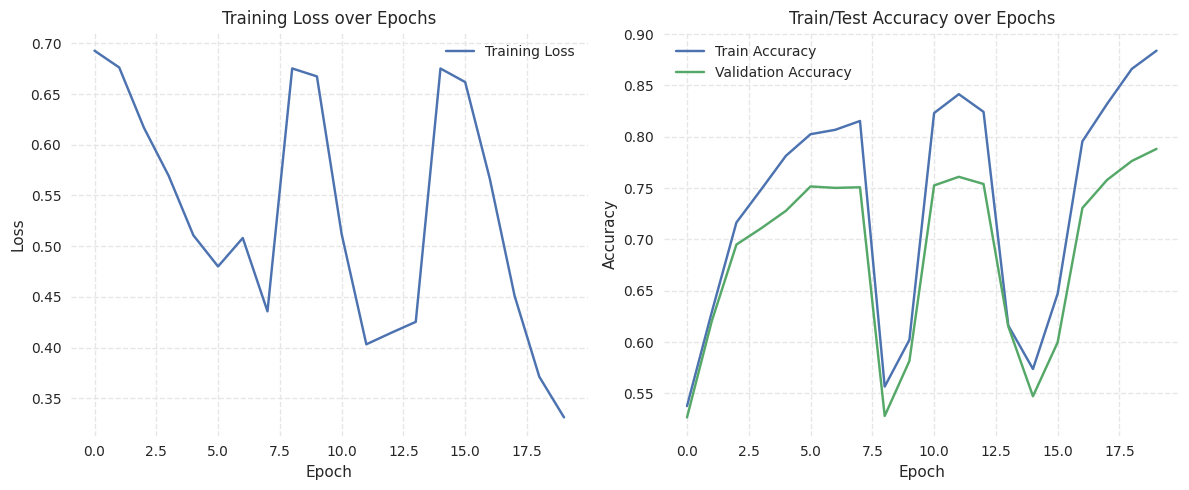

In [10]:
vocab_size = len(tokenizer.vocab)
lstm_model = LSTMModel(vocab_size, embedding_dim=128, hidden_dim=256, num_classes=2)
lstm_model.to(device)
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-4)
training_metrics  = train_model_with_test_accuracy(lstm_model, train_loader, valid_loader, test_loader, lstm_criterion, lstm_optimizer, device, epochs=20, model_name="lstm")

state_dict = torch.load('/kaggle/working/best_lstm_model.pth', weights_only=True)
lstm_model.load_state_dict(state_dict)

test_results = evaluate_model_final(lstm_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

lstm_loss = training_metrics['train_losses']
lstm_train_accuracies = training_metrics['train_accuracies']
lstm_val_accuracies = training_metrics['val_accuracies']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(training_metrics['train_losses'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_metrics['train_accuracies'], label='Train Accuracy')
plt.plot(training_metrics['val_accuracies'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/Test Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/20


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.00it/s]


训练损失: 0.4959486241340637, 训练准确率: 0.84845, 验证准确率: 0.803
Epoch 1 完成, 耗时: 71.65s
Epoch 2/20


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.17it/s]


训练损失: 0.35283349134922026, 训练准确率: 0.9055, 验证准确率: 0.8162
Epoch 2 完成, 耗时: 71.48s
Epoch 3/20


...

训练损失: 0.010530839049541465, 训练准确率: 0.9981, 验证准确率: 0.7904
Epoch 19 完成, 耗时: 71.12s
Epoch 20/20


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.23it/s]


训练损失: 0.01338396547248667, 训练准确率: 0.9977, 验证准确率: 0.788
Epoch 20 完成, 耗时: 71.36s
best_epoch: 2
all_time: 1436.8186933994293


Evaluating: 100%|██████████| 782/782 [00:35<00:00, 21.81it/s]


测试集准确率: 0.7993
积极情感准确率: 0.7683
消极情感准确率: 0.8302


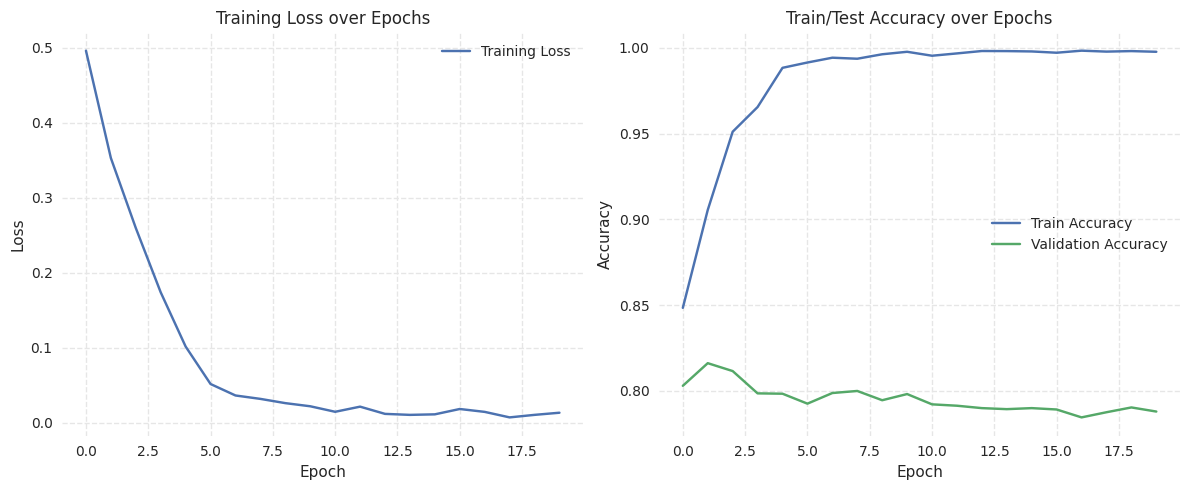

In [11]:
transformer_model = TransformerModel(num_heads=8, d_model=256, num_classes=2)
transformer_model.to(device)
transformer_criterion = nn.CrossEntropyLoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)
training_metrics = train_model_with_test_accuracy(transformer_model, train_loader, valid_loader, test_loader, transformer_criterion, transformer_optimizer, device, epochs=20, model_name="transformer")
state_dict = torch.load('/kaggle/working/best_transformer_model.pth', weights_only=True)
transformer_model.load_state_dict(state_dict)
test_results = evaluate_model_final(transformer_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")
transformer_loss = training_metrics['train_losses']
transformer_train_accuracies = training_metrics['train_accuracies']
transformer_val_accuracies = training_metrics['val_accuracies']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(training_metrics['train_losses'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_metrics['train_accuracies'], label='Train Accuracy')
plt.plot(training_metrics['val_accuracies'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/Test Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

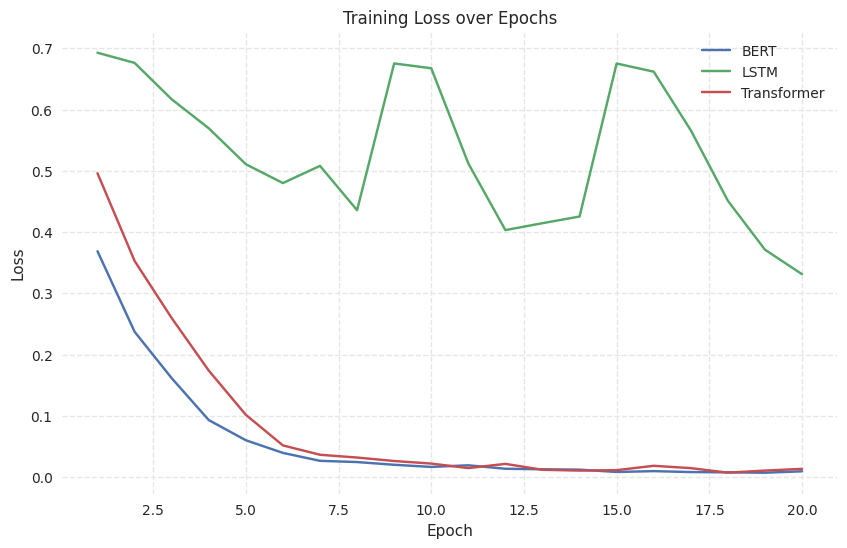

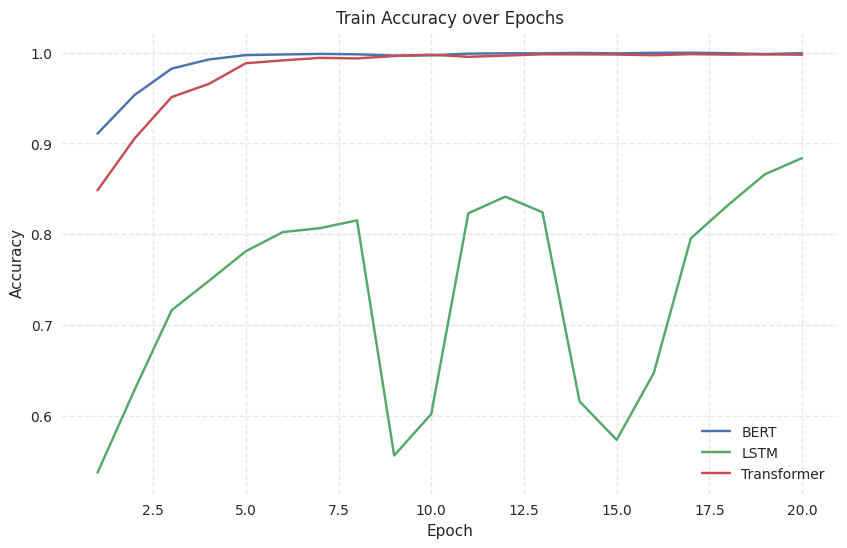

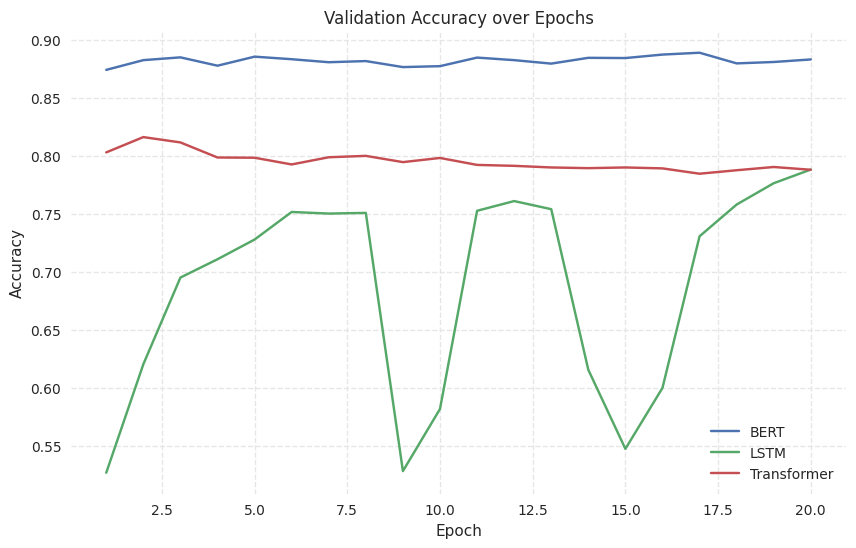

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), bert_loss, label='BERT')
plt.plot(range(1, 21), lstm_loss, label='LSTM')
plt.plot(range(1, 21), transformer_loss, label='Transformer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), bert_train_accuracies, label='BERT')
plt.plot(range(1, 21), lstm_train_accuracies, label='LSTM')
plt.plot(range(1, 21), transformer_train_accuracies, label='Transformer')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train Accuracy over Epochs')
plt.legend()

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), bert_val_accuracies, label='BERT')
plt.plot(range(1, 21), lstm_val_accuracies, label='LSTM')
plt.plot(range(1, 21), transformer_val_accuracies, label='Transformer')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.legend()